# 04 ? Geoqu?mica por clases y control RGB

Se admite distancia RGB m?xima 2 y separaci?n m?nima 10 respecto a la segunda clase. Esto admite peque?as diferencias de exportaci?n de color; no valida leyendas, medios ni extracciones. Las discrepancias de 8 niveles de Zn/W siguen rechazadas. Se informa de las coincidencias exactas y tolerancias 2/8 sobre tierra. Clase cero v?lida; no confundir con NoData. Moda y proporciones son representaciones alternativas.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/geoau/features.py').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd
import matplotlib.pyplot as plt
from geoau import features as fd

import importlib
importlib.reload(fd)
RUN = fd.current_run(ROOT)
print(RUN)
import importlib.metadata
fd.write_json(RUN / 'environment_fase_d.json', {p: importlib.metadata.version(p) for p in ('numpy', 'scipy', 'pyarrow')})

C:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\reports\fase_d\20260909T104712_606095Z


In [2]:
geochemistry, geochemistry_quality = fd.geochemistry(ROOT, RUN)
display(pd.read_csv(RUN / 'geoquimica_rgb_qc.csv'))

Bloque verificado: geochemistry


,element,valid_native_original_land,accepted_native_land,rejected_native_land,modal_changed_vs_C,cells_sufficient_rgb,official_legend_validated,rgb_max_distance,rgb_min_class_margin,pixels_exact_land,pixels_within_2_land,pixels_within_8_land
0,Au,1956430,1956430,0,0,488096,False,2.0,10.0,1956430,1956430,1956430
1,As,1956430,1956430,0,0,488096,False,2.0,10.0,1956430,1956430,1956430
2,Sb,1950793,1950793,0,0,486473,False,2.0,10.0,1950793,1950793,1950793
3,Bi,1956430,1956430,0,0,488096,False,2.0,10.0,1956430,1956430,1956430
4,Hg,1956430,1956430,0,0,488096,False,2.0,10.0,518691,1956430,1956430
5,Cu,1956430,1956430,0,0,488096,False,2.0,10.0,480301,1956430,1956430
6,Pb,1954606,1954606,0,0,486857,False,2.0,10.0,500860,1954606,1954606
7,Zn,1956430,1482251,474179,16690,353302,False,2.0,10.0,575553,1482251,1956430
8,W,1956430,1731195,225235,19234,411627,False,2.0,10.0,666541,1731195,1956430


In [3]:
display(geochemistry.head())
display(geochemistry_quality.describe())

,cell_id,au_clase_modal,au_proporcion_clase_0,au_proporcion_clase_1,au_proporcion_clase_2,au_proporcion_clase_3,au_proporcion_clase_4,au_proporcion_clase_5,au_proporcion_clase_6,as_clase_modal,...,zn_proporcion_clase_6,zn_proporcion_clase_7,w_clase_modal,w_proporcion_clase_0,w_proporcion_clase_1,w_proporcion_clase_2,w_proporcion_clase_3,w_proporcion_clase_4,w_proporcion_clase_5,w_proporcion_clase_6
0,es_pen_utm30_1km_v1_r0000_c0172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,es_pen_utm30_1km_v1_r0000_c0173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,es_pen_utm30_1km_v1_r0001_c0172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,es_pen_utm30_1km_v1_r0001_c0173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,es_pen_utm30_1km_v1_r0001_c0174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,geoquimica_au_valid_rgb,geoquimica_as_valid_rgb,geoquimica_sb_valid_rgb,geoquimica_bi_valid_rgb,geoquimica_hg_valid_rgb,geoquimica_cu_valid_rgb,geoquimica_pb_valid_rgb,geoquimica_zn_valid_rgb,geoquimica_w_valid_rgb
count,496855.000000,496855.000000,496855.000000,496855.000000,496855.000000,496855.000000,496855.000000,496855.000000,496855.00000
mean,0.985814,0.985814,0.982954,0.985814,0.985814,0.985814,0.985252,0.746989,0.87239
std,0.112843,0.112843,0.123670,0.112843,0.112843,0.112843,0.112183,0.414064,0.29974
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.500000,1.00000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [4]:
# Cero es una clase v?lida: filtrar presencia de datos, no valores > 0.
cols_modal = geochemistry.columns[geochemistry.columns.str.endswith('_modal')]

df_limpio = geochemistry[geochemistry[cols_modal].notna().any(axis=1)]

df_limpio

,cell_id,au_clase_modal,au_proporcion_clase_0,au_proporcion_clase_1,au_proporcion_clase_2,au_proporcion_clase_3,au_proporcion_clase_4,au_proporcion_clase_5,au_proporcion_clase_6,as_clase_modal,...,zn_proporcion_clase_6,zn_proporcion_clase_7,w_clase_modal,w_proporcion_clase_0,w_proporcion_clase_1,w_proporcion_clase_2,w_proporcion_clase_3,w_proporcion_clase_4,w_proporcion_clase_5,w_proporcion_clase_6
65,es_pen_utm30_1km_v1_r0006_c0164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86,es_pen_utm30_1km_v1_r0007_c0151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87,es_pen_utm30_1km_v1_r0007_c0152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88,es_pen_utm30_1km_v1_r0007_c0153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89,es_pen_utm30_1km_v1_r0007_c0154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496846,es_pen_utm30_1km_v1_r0870_c0317,3.0,0.000000,0.0,0.000000,0.5,0.5,0.0,0.0,3.0,...,0.0,0.0,1.0,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0
496847,es_pen_utm30_1km_v1_r0870_c0318,4.0,0.000000,0.0,0.000000,0.0,1.0,0.0,0.0,3.0,...,0.0,0.0,1.0,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0
496849,es_pen_utm30_1km_v1_r0870_c0320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496851,es_pen_utm30_1km_v1_r0871_c0315,2.0,0.000000,0.0,1.000000,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,1.0,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0


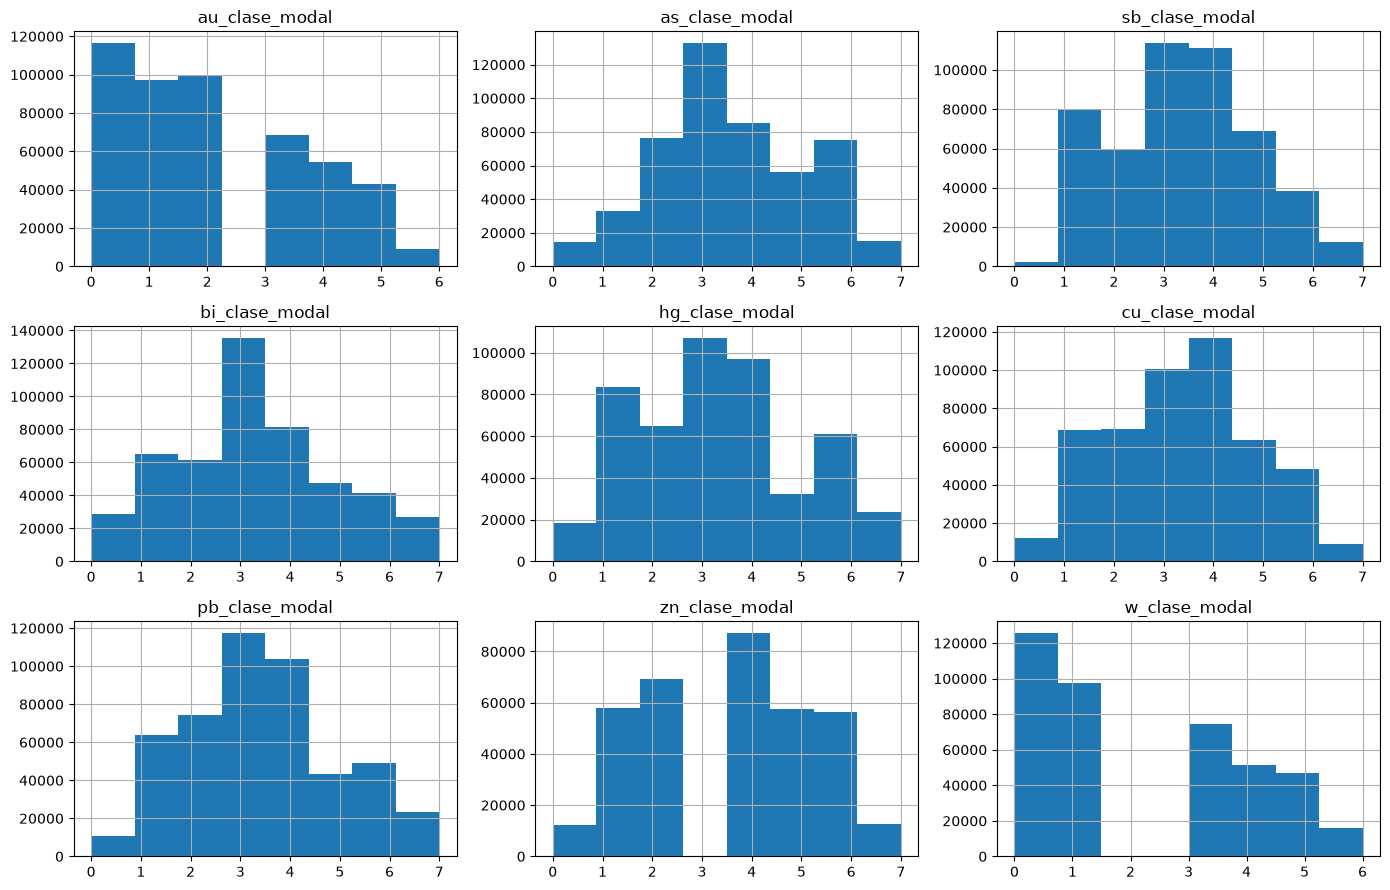

In [5]:
geochemistry.filter(regex='_clase_modal$').hist(figsize=(14, 9), bins=8)
plt.tight_layout()
plt.show()